# Hybrid recommendation Engine ()

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
import joblib
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [2]:
DATA_PATH = '../data/processed/clean_clothing_sales.csv' 
PIPELINE_SAVE_PATH = '../models/hybrid_recommender_pipeline.pkl'
SIM_MATRIX_SAVE_PATH = '../models/hybrid_similarity_matrix.npz'
SVD_SAVE_PATH =  '../models/svd_transformer.pkl'

In [3]:
df = pd.read_csv(DATA_PATH)
print('Data loaded. Shape:', df.shape)

Data loaded. Shape: (20252, 17)


In [4]:
df = df.fillna('missing')

In [5]:
# Create combined text features
text_cols = ['name', 'description', 'brand', 'terms', 'material']
df['text_feature'] = df[text_cols].astype(str).agg(' '.join, axis=1)

# Ensure 'promotion' is treated as a category/string for OHE
if 'promotion' in df.columns:
    df['promotion'] = df['promotion'].astype(str)
if 'seasonal' in df.columns:
    df['seasonal'] = df['seasonal'].astype(str)

# Reset index to a simple integer index and create stable product mappings
df = df.reset_index(drop=True)
product_id_to_index = pd.Series(df.index.values, index=df['product_id']).to_dict()
print("Product ID to Index mapping created for stable lookups.")

Product ID to Index mapping created for stable lookups.


In [6]:
TEXT_FEATURES = ['text_feature']
CATEGORICAL_FEATURES = [
    'product_position',
    'product_category',
    'section',
    'season',
    'material',
    'origin',
    'terms',
    'brand',
    'promotion',
    'seasonal'
]
NUMERIC_FEATURES = [
    'price' # Only price is used from the original numerical features
    # 'sales_volume' is explicitly excluded
]

In [7]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True) # Use sparse output for efficiency
scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('text_vec', tfidf, 'text_feature'),
        ('cat_ohe', ohe, CATEGORICAL_FEATURES),
        ('num_scale', scaler, NUMERIC_FEATURES)
    ],
    remainder='drop',
    sparse_threshold=0.1
)

pipeline = Pipeline(steps=[('preprocessor', preprocessor)])
print('Hybrid Feature Engineering Pipeline defined.')

Hybrid Feature Engineering Pipeline defined.


In [8]:
# Fit the pipeline and transform the data
print('Fitting pipeline and transforming data...')
full_matrix = pipeline.fit_transform(df)
print('Transformed hybrid matrix shape (sparse):', full_matrix.shape)

Fitting pipeline and transforming data...
Transformed hybrid matrix shape (sparse): (20252, 5013)


In [9]:
USE_DIM_REDUCTION = True
REDUCED_DIM = 300 

if USE_DIM_REDUCTION:
    # Use SVD to reduce dimensions and create a dense array for faster cosine similarity
    n_components = min(REDUCED_DIM, full_matrix.shape[1] - 1)
    print(f'Applying TruncatedSVD to {n_components} components...')
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    hybrid_matrix = svd.fit_transform(full_matrix)
    print('Reduced hybrid_matrix shape (dense):', hybrid_matrix.shape)
else:
    hybrid_matrix = full_matrix

Applying TruncatedSVD to 300 components...
Reduced hybrid_matrix shape (dense): (20252, 300)


In [10]:
# Compute Cosine Similarity Matrix
print('Computing dense cosine similarity matrix...')
# This is an N x N matrix (20252 x 20252), which requires substantial memory.
# The SVD step helps manage the size and quality.
sim_matrix = cosine_similarity(hybrid_matrix)
print('Similarity matrix shape:', sim_matrix.shape)

Computing dense cosine similarity matrix...


Similarity matrix shape: (20252, 20252)


 Save artifacts

In [ ]:


print(f'Saving similarity matrix to {SIM_MATRIX_SAVE_PATH}...')
# Use np.savez_compressed to save the large dense array efficiently (the uncompressed array was about 2GB)
np.savez_compressed(SIM_MATRIX_SAVE_PATH, matrix=sim_matrix)
print('Similarity matrix saved successfully.')

os.makedirs(os.path.dirname(PIPELINE_SAVE_PATH), exist_ok=True)
joblib.dump(pipeline, PIPELINE_SAVE_PATH)
if USE_DIM_REDUCTION:
    joblib.dump(svd, SVD_SAVE_PATH)
print(f'Pipeline saved to {PIPELINE_SAVE_PATH} and SVD saved to {SVD_SAVE_PATH}')

Saving similarity matrix to ../models/hybrid_similarity_matrix.npz...
Similarity matrix saved successfully.
Pipeline saved to ../models/hybrid_recommender_pipeline.pkl and SVD saved to ../models/svd_transformer.pkl


In [12]:
def recommend(product_id: str, top_n: int = 10, include_score: bool = False):
    """
    Return top_n similar products for a given product_id using the precomputed
    similarity matrix.
    """
    if product_id not in product_id_to_index:
        raise KeyError(f'Product id {product_id} not found in the dataset.')

    # Get the index (positional ID) corresponding to the stable product_id
    idx = product_id_to_index[product_id]

    # Get scores for this item
    scores = sim_matrix[idx]
    
    # Get indices sorted by similarity (descending), skip the first one (self)
    top_indices = np.argsort(scores)[::-1]
    
    # Filter out the query item's own index
    top_indices = top_indices[top_indices != idx][:top_n]

    results = df.iloc[top_indices].copy()
    
    # Select key display columns
    results = results[['product_id','name','section','price','season','material']].reset_index(drop=True)
    
    if include_score:
        results['score'] = scores[top_indices]
        
    return results

In [15]:
example_product_id = df['product_id'].iloc[2]

print('Query Product Details:')
print(df[df['product_id'] == example_product_id][['product_id', 'name', 'price', 'section', 'material', 'sales_volume']])

print('\nTop 5 Recommendations for ID:', example_product_id)
recommendations = recommend(product_id=example_product_id, top_n=5, include_score=True)
print(recommendations)

Query Product Details:
   product_id                  name  price section   material  sales_volume
2      180176  SLIM FIT SUIT JACKET  71.95   WOMAN  Polyester          1168

Top 5 Recommendations for ID: 180176
   product_id                                        name section  price  \
0      212263           QUILTED STRETCH SUIT JACKET TAUPE   WOMAN  49.99   
1      215763                  LEATHER BIKER JACKET WHITE   WOMAN  53.99   
2      215292           CROPPED PADDED BOMBER JACKET NAVY   WOMAN  72.95   
3      204014      CROPPED COLOR BLOCK PUFFER JACKET SAND   WOMAN  74.00   
4      201274  CROPPED EMBROIDERED FOREST JACKET SKY BLUE   WOMAN  69.99   

   season   material     score  
0  Autumn  Polyester  0.953248  
1  Autumn  Polyester  0.911938  
2  Autumn  Polyester  0.886493  
3  Autumn  Polyester  0.883567  
4  Autumn  Polyester  0.866642  


Top shared tokens between query and top recommendation:
[('fabric high', 0.02413959639117545), ('jackets polyester', 0.01650164251358613), ('high collar', 0.012071314456398315), ('polyester', 0.011512272281624948), ('jacket', 0.010443826534784796), ('hem', 0.00942688210455035), ('high', 0.009102767830797654), ('fabric', 0.00572516137179486), ('zara jackets', 0.003259101350265302), ('jackets', 0.003259101350265302)]
Running t-SNE for 2D visualization (this may take a minute)...


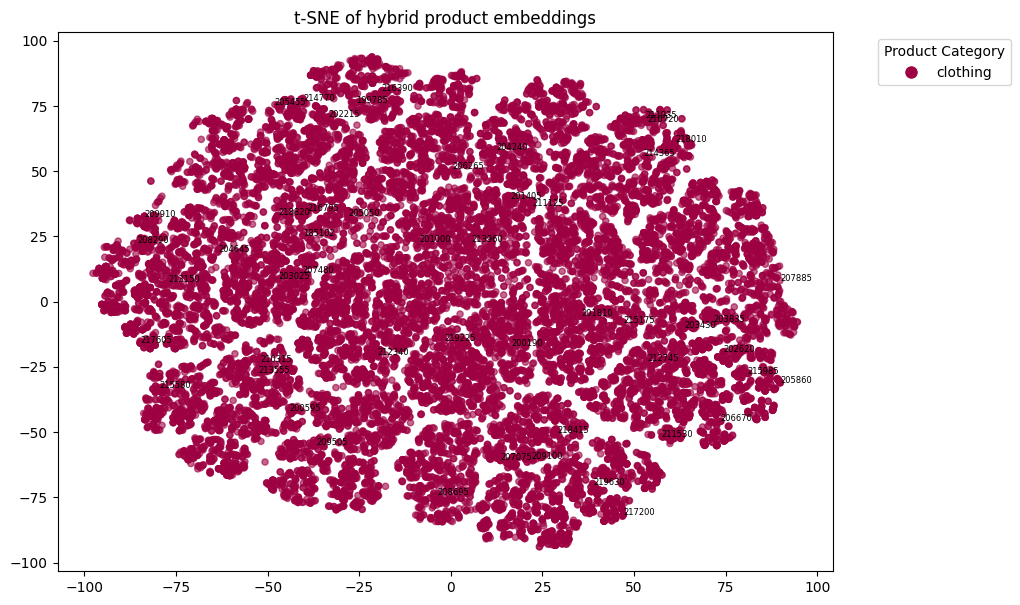

Done. The final cells for the rewritten hybrid recommender script are included.


In [14]:
# We can extract tfidf feature names and show overlapping high-tfidf tokens
try:
    # 1. Access the trained TF-IDF vectorizer from the pipeline
    tfidf_vectorizer = pipeline.named_steps['preprocessor'].named_transformers_['text_vec']
    feature_names = tfidf_vectorizer.get_feature_names_out()
    
    # Define the helper function
    def top_shared_tokens(idx_i, idx_j, topk=10):
        """Finds top common tokens between two product indices in the TF-IDF space."""
        
        # NOTE: df.loc[idx, 'text_feature'] returns the string content used for TF-IDF
        vec_i = tfidf_vectorizer.transform([df.loc[idx_i,'text_feature']])
        vec_j = tfidf_vectorizer.transform([df.loc[idx_j,'text_feature']])
        
        # Multiply element-wise to keep only common tokens and their combined weight
        common = np.asarray(vec_i.multiply(vec_j).todense()).ravel()
        top_idx = np.argsort(common)[::-1][:topk]
        
        tokens = [(feature_names[idx], float(common[idx])) for idx in top_idx if common[idx] > 0]
        return tokens

    # --- Demo Explainability ---
    
    # Retrieve the top recommendation details (using the stable product_id)
    recs = recommend(product_id=example_product_id, top_n=1, include_score=False)
    
    # Get the stable index for the query item (using the global dictionary)
    query_index = product_id_to_index[example_product_id]
    
    # Get the stable index for the recommended item using the global dictionary
    rec_id = recs.loc[0,'product_id']
    rec_index = product_id_to_index[rec_id]
    
    print('Top shared tokens between query and top recommendation:')
    print(top_shared_tokens(query_index, rec_index, topk=10))
    
except Exception as e:
    print('Explainability step skipped (Error in TF-IDF extraction or function call):', e)

# Visualization: 2D t-SNE plot of product vectors colored by product_category
VISUALIZE = True
if VISUALIZE:
    print('Running t-SNE for 2D visualization (this may take a minute)...')
    
    # Check if SVD was applied and use the resulting dense matrix
    if 'svd' in locals() and hybrid_matrix.shape[1] < full_matrix.shape[1]:
        matrix_to_plot = hybrid_matrix
    else:
        # Fallback if SVD was not used, requires full_matrix to be dense or converts it
        matrix_to_plot = full_matrix.todense() if hasattr(full_matrix, 'todense') else full_matrix

    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', n_jobs=-1)
    emb = tsne.fit_transform(matrix_to_plot)
    
    plt.figure(figsize=(10,7))
    categories = df['product_category'].astype(str)
    unique_cats = categories.unique()
    cat_to_int = {c:i for i,c in enumerate(unique_cats)}
    colors = [cat_to_int[c] for c in categories]
    
    scatter = plt.scatter(emb[:,0], emb[:,1], c=colors, alpha=0.6, s=20, cmap='Spectral')
    plt.title('t-SNE of hybrid product embeddings')
    
    # Create legend handles for categories
    legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=cat, 
                                markerfacecolor=scatter.cmap(scatter.norm(cat_to_int[cat])), markersize=10) 
                      for cat in unique_cats]
    plt.legend(handles=legend_handles, title="Product Category", bbox_to_anchor=(1.05, 1), loc='upper left')

    # optional: annotate a handful of points
    for i in range(0, len(df), max(1, len(df)//50)):
        plt.text(emb[i,0], emb[i,1], str(df.loc[i,'product_id']), fontsize=6)
        
    plt.show()


print('Done. The final cells for the rewritten hybrid recommender script are included.')